In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Hotel Reservations.csv')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [3]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [4]:
df=df.drop(columns=['Booking_ID'])

In [5]:
df=pd.get_dummies(df,drop_first=True)
df.sample()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_Not_Canceled
27401,2,0,0,1,0,11,2018,6,2,0,...,False,False,False,False,False,False,False,False,True,False


In [6]:
x=df.drop(columns=['booking_status_Not_Canceled'])
y=df['booking_status_Not_Canceled']

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((29020, 27), (7255, 27), (29020,), (7255,))

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,mean_squared_error


In [9]:
ac=[]
mse=[]
for i in range(1,21):
    model=KNeighborsClassifier(i)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    ac.append(accuracy_score(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))

In [10]:
for i in range(1,21):
    print(f"Value of k = {i} acuuracy = {ac[i-1]}")

Value of k = 1 acuuracy = 0.8111647139903515
Value of k = 2 acuuracy = 0.7607167470709856
Value of k = 3 acuuracy = 0.8108890420399725
Value of k = 4 acuuracy = 0.7880082701585114
Value of k = 5 acuuracy = 0.808959338387319
Value of k = 6 acuuracy = 0.7976567884217781
Value of k = 7 acuuracy = 0.808959338387319
Value of k = 8 acuuracy = 0.7993108201240524
Value of k = 9 acuuracy = 0.8053756030323914
Value of k = 10 acuuracy = 0.7987594762232942
Value of k = 11 acuuracy = 0.808959338387319
Value of k = 12 acuuracy = 0.8022053756030324
Value of k = 13 acuuracy = 0.8068917987594763
Value of k = 14 acuuracy = 0.8022053756030324
Value of k = 15 acuuracy = 0.8066161268090972
Value of k = 16 acuuracy = 0.8044107512060648
Value of k = 17 acuuracy = 0.8073053066850447
Value of k = 18 acuuracy = 0.8056512749827704
Value of k = 19 acuuracy = 0.8044107512060648
Value of k = 20 acuuracy = 0.8002756719503791


In [11]:
print(max(ac))

0.8111647139903515


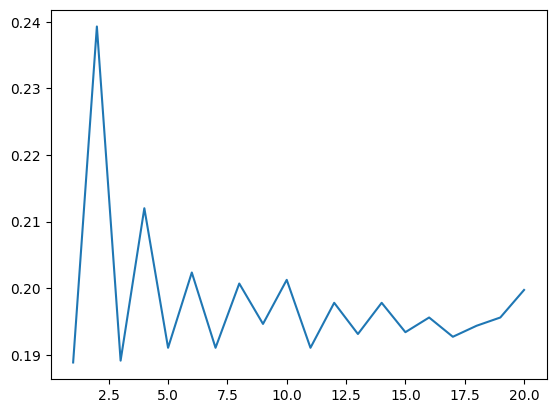

In [12]:
plt.plot(list(range(1,21)),mse)
plt.show()

#### Thus k = 1 gives us the highest accuracy

##### making a model with k = 1

In [13]:
model=KNeighborsClassifier(1)
model.fit(x_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
df.sample()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   required_car_parking_space            36275 non-null  int64  
 5   lead_time                             36275 non-null  int64  
 6   arrival_year                          36275 non-null  int64  
 7   arrival_month                         36275 non-null  int64  
 8   arrival_date                          36275 non-null  int64  
 9   repeated_guest                        36275 non-null  int64  
 10  no_of_previous_cancellations          36275 non-null  int64  
 11  no_of_previous_

In [15]:
predict=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
predict

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([False])

# With Decision Tree

In [16]:
from sklearn.tree import DecisionTreeClassifier,plot_tree


In [17]:
ac=[]
mse=[]
for i in range(1,21):
    model=DecisionTreeClassifier(criterion='entropy',max_depth=i,random_state=42)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    ac.append(accuracy_score(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))

In [18]:
for i in range(1,21):
    print(f"Value of max depth = {i} acuuracy = {ac[i-1]}")

Value of max depth = 1 acuuracy = 0.7651274982770503
Value of max depth = 2 acuuracy = 0.7651274982770503
Value of max depth = 3 acuuracy = 0.7830461750516885
Value of max depth = 4 acuuracy = 0.8137835975189525
Value of max depth = 5 acuuracy = 0.830737422467264
Value of max depth = 6 acuuracy = 0.833907649896623
Value of max depth = 7 acuuracy = 0.850999310820124
Value of max depth = 8 acuuracy = 0.8578911095796002
Value of max depth = 9 acuuracy = 0.867539627842867
Value of max depth = 10 acuuracy = 0.868090971743625
Value of max depth = 11 acuuracy = 0.8745692625775328
Value of max depth = 12 acuuracy = 0.8796691936595451
Value of max depth = 13 acuuracy = 0.8781529979324604
Value of max depth = 14 acuuracy = 0.882012405237767
Value of max depth = 15 acuuracy = 0.8784286698828394
Value of max depth = 16 acuuracy = 0.878566505858029
Value of max depth = 17 acuuracy = 0.8773259820813232
Value of max depth = 18 acuuracy = 0.8773259820813232
Value of max depth = 19 acuuracy = 0.8766368

In [19]:
print(f'Max acurracy is {max(ac)} and max depth is {1+ac.index(max(ac))} ')

Max acurracy is 0.882012405237767 and max depth is 14 


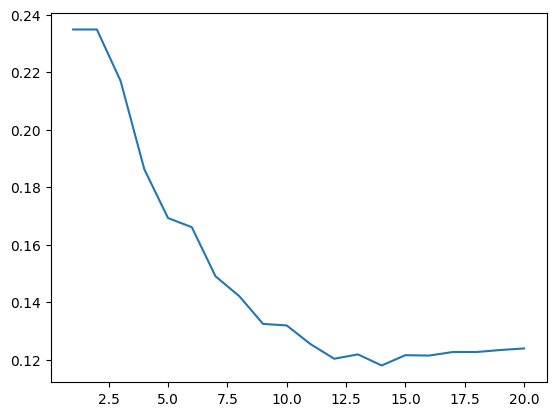

In [20]:
plt.plot(list(range(1,21)),mse)
plt.show()

#### Now making model with depth = 14

In [21]:
model=DecisionTreeClassifier(criterion='entropy',max_depth=14,random_state=42)
model.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
predict=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
predict

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([ True])

# With Random forest 

In [23]:
from sklearn.ensemble import RandomForestClassifier


In [24]:
ac=[]
mse=[]
for i in range(51,71):
    model=RandomForestClassifier(n_estimators=i,max_depth=5,random_state=42)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    ac.append(accuracy_score(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))

In [25]:
for i in range(1,21):
    print(f"Value of n  = {i+50} acuuracy = {ac[i-1]}")

Value of n  = 51 acuuracy = 0.8283942108890421
Value of n  = 52 acuuracy = 0.8250861474844935
Value of n  = 53 acuuracy = 0.8263266712611992
Value of n  = 54 acuuracy = 0.8231564438318401
Value of n  = 55 acuuracy = 0.822880771881461
Value of n  = 56 acuuracy = 0.822329427980703
Value of n  = 57 acuuracy = 0.8245348035837353
Value of n  = 58 acuuracy = 0.819434872501723
Value of n  = 59 acuuracy = 0.8206753962784287
Value of n  = 60 acuuracy = 0.8158511371467954
Value of n  = 61 acuuracy = 0.8172294968986905
Value of n  = 62 acuuracy = 0.816815988973122
Value of n  = 63 acuuracy = 0.8172294968986905
Value of n  = 64 acuuracy = 0.8150241212956582
Value of n  = 65 acuuracy = 0.8147484493452791
Value of n  = 66 acuuracy = 0.8151619572708477
Value of n  = 67 acuuracy = 0.8183321847002067
Value of n  = 68 acuuracy = 0.8155754651964162
Value of n  = 69 acuuracy = 0.8125430737422468
Value of n  = 70 acuuracy = 0.8141971054445211


In [26]:
print(f'Max acurracy is {max(ac)} and max n is {1+ac.index(max(ac))}')

Max acurracy is 0.8283942108890421 and max n is 1


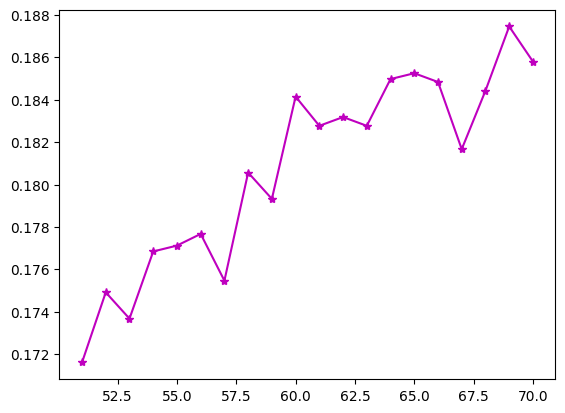

In [27]:
plt.plot(list(range(51,71)),mse,'*-m')
plt.show()

#### Now making model with n estimeters = 51

In [28]:
model=RandomForestClassifier(n_estimators=51,max_depth=5,random_state=42)
model.fit(x_train,y_train)

,n_estimators,51
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
predict=model.predict([[2,1,2,3,0,120,2023,8,15,0,0,1,110.5,1,0,0,0,0,0,0,0,0,0,0,0,0,1]])
predict

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [30]:
model=RandomForestClassifier(n_estimators=51,max_depth=20,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.9011716057891109